# **CHALLENGE TÉCNICO CORE:**
**Predicción de la clase estelar - Kaggle Playground S6E6**

**Objetivo:** desarrollar y comparar modelos de clasificación multiclase para predecir si una observación astronómica corresponde a una estrella (`STAR`), una galaxia (`GALAXY`) o un cuásar (`QSO`).

La competencia utiliza la métrica **balanced accuracy**, apropiada para evaluar el desempeño de manera equilibrada entre las tres clases, evitando que la clase más frecuente domine artificialmente la evaluación.

# **1. Carga y Exploración Inicial de Datos:**

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Rutas de archivos cargados en Colab
RUTA_TRAIN = "/content/drive/MyDrive/train.csv"
RUTA_TEST = "/content/drive/MyDrive/test.csv"
RUTA_SUBMISSION = "/content/drive/MyDrive/sample_submission.csv"

# Validar que los tres archivos estén disponibles
for ruta in [RUTA_TRAIN, RUTA_TEST, RUTA_SUBMISSION]:
    if not os.path.exists(ruta):
        raise FileNotFoundError(
            f"No se encontró el archivo: {ruta}. "
            "Verifica que lo hayas cargado en el panel de archivos de Colab."
        )

# Cargar datasets
train = pd.read_csv(RUTA_TRAIN)
test = pd.read_csv(RUTA_TEST)
sample_submission = pd.read_csv(RUTA_SUBMISSION)

print("Datasets cargados correctamente.\n")

print("Dimensiones:")
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")
print(f"Sample submission: {sample_submission.shape}")

Datasets cargados correctamente.

Dimensiones:
Train: (577347, 12)
Test: (247435, 11)
Sample submission: (247435, 2)


El conjunto de entrenamiento contiene 577.347 observaciones y 12 variables, mientras que el conjunto de prueba incluye 247.435 registros sin la variable objetivo. La tarea corresponde a una clasificación multiclase: identificar si cada observación astronómica pertenece a la clase `STAR`, `GALAXY` o `QSO`.

Se verificará la estructura de las variables, los tipos de datos, valores faltantes, duplicados y distribución inicial de la clase objetivo antes de construir los modelos.

**1.1 EXPLORACIÓN INICIAL DEL DATASET**

In [4]:
print("Dimensiones del conjunto de entrenamiento:", train.shape)
print("Dimensiones del conjunto de prueba:", test.shape)

print("\nColumnas disponibles en train:")
print(train.columns.tolist())

print("\nColumnas disponibles en test:")
print(test.columns.tolist())

print("\nTipos de datos, valores no nulos y cardinalidad:")
resumen_estructura = pd.DataFrame({
    "Variable": train.columns,
    "Tipo de dato": train.dtypes.astype(str).values,
    "Valores no nulos": train.notnull().sum().values,
    "Valores únicos": train.nunique().values
})

display(resumen_estructura)

print("\nPrimeras cinco observaciones del conjunto de entrenamiento:")
display(train.head())

Dimensiones del conjunto de entrenamiento: (577347, 12)
Dimensiones del conjunto de prueba: (247435, 11)

Columnas disponibles en train:
['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'class']

Columnas disponibles en test:
['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population']

Tipos de datos, valores no nulos y cardinalidad:


,Variable,Tipo de dato,Valores no nulos,Valores únicos
0,id,int64,577347,577347
1,alpha,float64,577347,439819
2,delta,float64,577347,444062
3,u,float64,577347,577347
4,g,float64,577347,577347
5,r,float64,577347,577347
6,i,float64,577347,577347
7,z,float64,577347,577347
8,redshift,float64,577347,573975
9,spectral_type,object,577347,4



Primeras cinco observaciones del conjunto de entrenamiento:


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


El conjunto de entrenamiento contiene 577.347 observaciones y 11 variables predictoras, además de la variable objetivo `class`. Las variables numéricas corresponden a mediciones astronómicas y fotométricas, mientras que `spectral_type` y `galaxy_population` son variables categóricas. La columna `id` identifica de forma única cada observación, por lo que no representa un atributo físico del objeto astronómico y será excluida del modelamiento para evitar que el modelo aprenda patrones artificiales asociados al orden de registro.


**1.1 EXPLORACIÓN INICIAL DEL DATASET**

In [2]:
print("Columnas de train:")
print(train.columns.tolist())

print("\nColumnas de test:")
print(test.columns.tolist())

print("\nInformación general del conjunto de entrenamiento:")
train.info()

print("\nPrimeras cinco filas:")
display(train.head())

print("\nValores faltantes por variable:")
faltantes = pd.DataFrame({
    "Valores faltantes": train.isna().sum(),
    "Porcentaje (%)": (train.isna().mean() * 100).round(3),
    "Tipo de dato": train.dtypes
}).sort_values("Valores faltantes", ascending=False)

display(faltantes)

print(f"\nRegistros duplicados en train: {train.duplicated().sum():,}")
print(f"Identificadores 'id' duplicados: {train['id'].duplicated().sum():,}")

print("\nDistribución de la variable objetivo:")
distribucion_clases = pd.DataFrame({
    "Cantidad": train["class"].value_counts(),
    "Porcentaje (%)": (train["class"].value_counts(normalize=True) * 100).round(2)
})

display(distribucion_clases)

Columnas de train:
['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'class']

Columnas de test:
['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population']

Información general del conjunto de entrenamiento:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 1

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY



Valores faltantes por variable:


,Valores faltantes,Porcentaje (%),Tipo de dato
id,0,0.0,int64
alpha,0,0.0,float64
delta,0,0.0,float64
u,0,0.0,float64
g,0,0.0,float64
r,0,0.0,float64
i,0,0.0,float64
z,0,0.0,float64
redshift,0,0.0,float64
spectral_type,0,0.0,object



Registros duplicados en train: 0
Identificadores 'id' duplicados: 0

Distribución de la variable objetivo:


,Cantidad,Porcentaje (%)
class,,
GALAXY,377480,65.38
QSO,117143,20.29
STAR,82724,14.33


**Hallazgos iniciales**

El conjunto de entrenamiento no contiene valores faltantes ni registros duplicados, por lo que no requiere imputación ni eliminación de observaciones en esta etapa. La variable `id` es un identificador único y será excluida del modelamiento, ya que no representa una característica astronómica predictiva.

La variable objetivo presenta desbalance de clases: GALAXY concentra el 65,38% de las observaciones, seguida por QSO (20,29%) y STAR (14,33%). En consecuencia, la exactitud simple podría sobreestimar el desempeño de modelos que favorezcan la clase mayoritaria. Para una evaluación más equilibrada se utilizará `balanced_accuracy` como métrica principal de benchmark y validación cruzada estratificada.

**1.2 Valores faltantes, duplicados e identificadores**

In [5]:
faltantes_train = pd.DataFrame({
    "Valores faltantes": train.isnull().sum(),
    "Porcentaje (%)": (train.isnull().mean() * 100).round(4),
    "Tipo de dato": train.dtypes.astype(str)
})

print("Valores faltantes en train:")
display(faltantes_train)

faltantes_test = pd.DataFrame({
    "Valores faltantes": test.isnull().sum(),
    "Porcentaje (%)": (test.isnull().mean() * 100).round(4),
    "Tipo de dato": test.dtypes.astype(str)
})

print("Valores faltantes en test:")
display(faltantes_test)

duplicados_train = train.duplicated().sum()
duplicados_test = test.duplicated().sum()

print(f"Registros duplicados en train: {duplicados_train}")
print(f"Registros duplicados en test: {duplicados_test}")

print(f"Identificadores 'id' duplicados en train: {train['id'].duplicated().sum()}")
print(f"Identificadores 'id' duplicados en test: {test['id'].duplicated().sum()}")

Valores faltantes en train:


,Valores faltantes,Porcentaje (%),Tipo de dato
id,0,0.0,int64
alpha,0,0.0,float64
delta,0,0.0,float64
u,0,0.0,float64
g,0,0.0,float64
r,0,0.0,float64
i,0,0.0,float64
z,0,0.0,float64
redshift,0,0.0,float64
spectral_type,0,0.0,object


Valores faltantes en test:


,Valores faltantes,Porcentaje (%),Tipo de dato
id,0,0.0,int64
alpha,0,0.0,float64
delta,0,0.0,float64
u,0,0.0,float64
g,0,0.0,float64
r,0,0.0,float64
i,0,0.0,float64
z,0,0.0,float64
redshift,0,0.0,float64
spectral_type,0,0.0,object


Registros duplicados en train: 0
Registros duplicados en test: 0
Identificadores 'id' duplicados en train: 0
Identificadores 'id' duplicados en test: 0


El conjunto de entrenamiento y el conjunto de prueba no presentan valores faltantes, registros duplicados ni identificadores repetidos. Por tanto, no será necesario aplicar técnicas de imputación ni eliminación de duplicados. La columna id es única en ambos conjuntos y se utilizará exclusivamente para mantener la trazabilidad de las observaciones y para generar el archivo de envío a Kaggle; se excluirá de las variables predictoras, ya que no representa una característica astronómica relevante para clasificar los objetos

**1.3 Identificación y documentación de valores atípicos**

In [6]:

variables_numericas = [
    "alpha", "delta", "u", "g", "r",
    "i", "z", "redshift"
]

def resumen_outliers_iqr(dataframe, columnas):
    resultados = []

    for columna in columnas:
        serie = dataframe[columna].dropna()

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        cantidad_outliers = (
            (serie < limite_inferior) |
            (serie > limite_superior)
        ).sum()

        resultados.append({
            "Variable": columna,
            "Q1": round(q1, 4),
            "Q3": round(q3, 4),
            "IQR": round(iqr, 4),
            "Límite inferior": round(limite_inferior, 4),
            "Límite superior": round(limite_superior, 4),
            "Cantidad outliers": cantidad_outliers,
            "Porcentaje outliers (%)": round(
                cantidad_outliers / len(serie) * 100, 2
            )
        })

    return pd.DataFrame(resultados)

resumen_outliers = resumen_outliers_iqr(train, variables_numericas)

print("Resumen de valores atípicos detectados mediante IQR:")
display(resumen_outliers)

Resumen de valores atípicos detectados mediante IQR:


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad outliers,Porcentaje outliers (%)
0,alpha,132.1615,231.8297,99.6682,-17.3408,381.3320,0,0.00
1,delta,2.4741,36.9883,34.5142,-49.2972,88.7596,0,0.00
2,u,20.9771,23.8691,2.8920,16.6391,28.2071,315,0.05
3,g,19.8650,22.2927,2.4277,16.2234,25.9343,2806,0.49
4,r,18.8207,21.1641,2.3434,15.3055,24.6792,1677,0.29
5,i,18.3068,20.6082,2.3014,14.8548,24.0602,1277,0.22
6,z,17.9732,20.1621,2.1889,14.6898,23.4455,1476,0.26
7,redshift,0.1811,0.8814,0.7003,-0.8695,1.9319,52590,9.11


**Interpretación de valores atípicos.**

La detección de valores atípicos se realizó mediante el método del rango intercuartílico (IQR), considerando como posibles outliers aquellos registros ubicados por debajo de Q1 - 1,5 × IQR o por sobre Q3 + 1,5 × IQR.

Los resultados muestran que las variables `alpha` y `delta` no presentan valores atípicos, lo cual es esperable porque corresponden a coordenadas astronómicas dentro de rangos definidos. En cambio, las variables fotométricas `u`, `g`, `r`, `i` y `z` presentan una proporción baja de valores atípicos, inferior al 1% en todos los casos. Esto indica que existen algunas observaciones extremas en las magnitudes registradas, pero no representan un volumen relevante dentro del conjunto de datos.

La variable `redshift` presenta la mayor proporción de valores atípicos, con 52.590 registros, equivalentes al 9,11% del conjunto de entrenamiento. Este resultado es analíticamente importante, ya que `redshift` mide el desplazamiento al rojo y puede estar asociado a diferencias reales entre objetos astronómicos como estrellas, galaxias y cuásares. Por esta razón, eliminar estos registros podría significar pérdida de información relevante para la clasificación.

En consecuencia, los valores atípicos serán documentados, pero no eliminados en esta etapa. Se mantendrán dentro del conjunto de datos para evitar descartar patrones potencialmente útiles para el modelo predictivo. Posteriormente, durante el preprocesamiento y entrenamiento, se evaluará si el modelo requiere transformación, escalamiento o algún tratamiento adicional para manejar la asimetría y dispersión de estas variables.


**1.4 Visualización de valores atípicos**

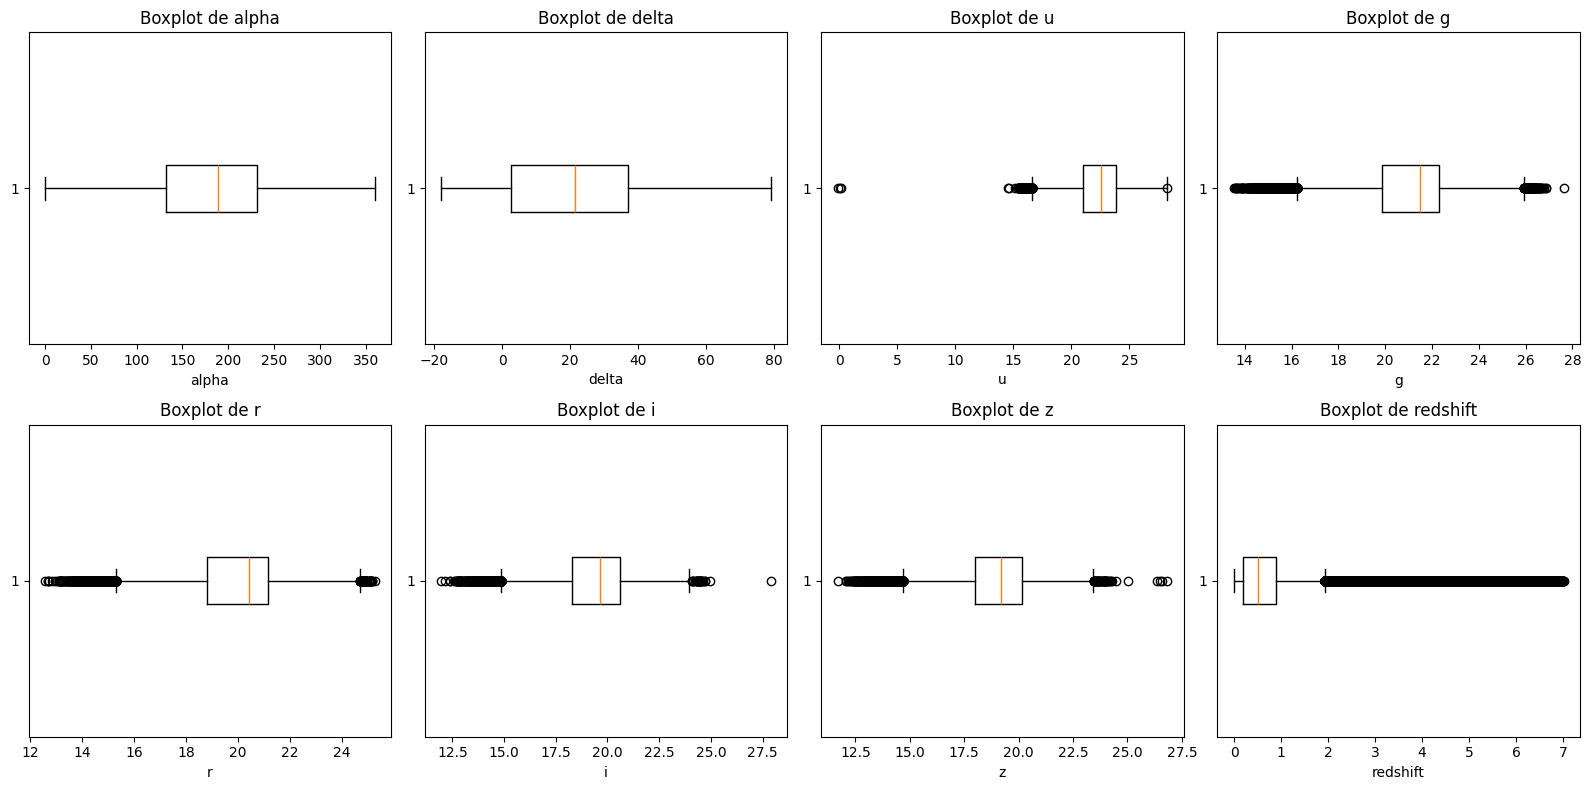

In [7]:
import math
import matplotlib.pyplot as plt

n_columnas = 4
n_filas = math.ceil(len(variables_numericas) / n_columnas)

fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(16, 4 * n_filas)
)

axes = axes.flatten()

for i, columna in enumerate(variables_numericas):
    axes[i].boxplot(train[columna], vert=False)
    axes[i].set_title(f"Boxplot de {columna}")
    axes[i].set_xlabel(columna)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Los diagramas de caja confirman los resultados obtenidos mediante el método IQR. Las coordenadas astronómicas alpha y delta presentan distribuciones acotadas y no evidencian valores atípicos relevantes.

Las variables fotométricas u, g, r, i y z muestran observaciones extremas en ambos extremos de su distribución, aunque su concentración principal se mantiene acotada. Debido a que estas variables representan magnitudes medidas en distintos filtros espectrales, los valores extremos pueden corresponder a objetos con características físicas particulares y no necesariamente a errores de medición.

La variable redshift presenta una asimetría positiva marcada y una gran concentración de observaciones por encima del límite superior calculado mediante IQR. Esto sugiere la existencia de objetos con desplazamiento al rojo elevado, potencialmente asociados a galaxias o cuásares más distantes. Por tanto, no se eliminarán los valores atípicos en esta fase, ya que podrían contener señal predictiva importante para distinguir las tres clases astronómicas.

El tratamiento posterior considerará escalamiento robusto o transformaciones sobre las variables con alta asimetría, particularmente redshift, evitando eliminar información potencialmente relevante para la clasificación multiclase.

# **2. Análisis Exploratorio de Datos (EDA)**

**2.1 Estadísticas descriptivas de variables numéricas**

In [8]:
# Se excluye "id" porque es un identificador técnico y no una
# característica física útil para describir los objetos astronómicos.

variables_numericas_eda = [
    "alpha", "delta", "u", "g", "r", "i", "z", "redshift"
]

estadisticas_numericas = train[variables_numericas_eda].describe().T

estadisticas_numericas["mediana"] = (
    train[variables_numericas_eda]
    .median()
)

estadisticas_numericas["varianza"] = (
    train[variables_numericas_eda]
    .var()
)

estadisticas_numericas["asimetria"] = (
    train[variables_numericas_eda]
    .skew()
)

estadisticas_numericas = estadisticas_numericas[
    [
        "count",
        "mean",
        "mediana",
        "std",
        "varianza",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "asimetria"
    ]
].round(4)

print("Estadísticas descriptivas de variables numéricas:")
display(estadisticas_numericas)

Estadísticas descriptivas de variables numéricas:


,count,mean,mediana,std,varianza,min,25%,50%,75%,max,asimetria
alpha,577347.0,181.6167,188.6815,96.2429,9262.7037,0.0117,132.1615,188.6815,231.8297,359.9998,-0.0553
delta,577347.0,21.8347,21.4844,18.9336,358.4801,-17.9670,2.4741,21.4844,36.9883,79.1583,0.1754
u,577347.0,22.4419,22.5702,2.0181,4.0729,-0.1392,20.9771,22.5702,23.8691,28.2533,-0.1166
g,577347.0,21.0073,21.4678,1.7954,3.2236,13.5355,19.8650,21.4678,22.2927,27.6202,-0.6288
r,577347.0,19.9628,20.4312,1.6490,2.7191,12.5794,18.8207,20.4312,21.1641,25.2545,-0.6623
i,577347.0,19.3789,19.6316,1.5801,2.4966,11.9628,18.3068,19.6316,20.6082,27.9109,-0.4803
z,577347.0,19.0411,19.1886,1.5844,2.5102,11.6828,17.9732,19.1886,20.1621,26.8269,-0.3140
redshift,577347.0,0.7231,0.4975,0.8101,0.6562,-0.0100,0.1811,0.4975,0.8814,7.0108,2.3047


Las estadísticas descriptivas permiten caracterizar el comportamiento inicial de las variables numéricas del conjunto de entrenamiento. El dataset contiene 57.347 observaciones completas para cada variable numérica analizada, sin pérdida de registros en esta etapa.

Las variables `alpha` y `delta`, asociadas a coordenadas astronómicas, presentan rangos amplios pero esperables para variables de posición. `alpha` tiene una media de 181,6167 y una mediana de 188,6815, con una asimetría levemente negativa (-0,0553), lo que indica una distribución relativamente equilibrada. En el caso de `delta`, la media es 21,8377 y la mediana 21,8440, con asimetría positiva baja (0,1754), por lo que tampoco evidencia una distorsión relevante.

Las variables fotométricas `u`, `g`, `r`, `i` y `z` presentan medias y medianas cercanas entre sí, lo que sugiere distribuciones relativamente estables. Sin embargo, algunas variables como `g`, `r` e `i` muestran asimetría negativa moderada, lo que indica una mayor presencia de valores hacia el extremo inferior de la escala. Estas diferencias son importantes porque las magnitudes medidas en distintos filtros espectrales pueden aportar información relevante para distinguir entre estrellas, galaxias y cuásares.

La variable `redshift` presenta el comportamiento más diferenciado del conjunto. Su media es 0,7231, mientras que la mediana es 0,4975, con una asimetría positiva elevada de 2,3047. Esto confirma que la distribución está desplazada hacia valores bajos, pero con una cola derecha extensa, asociada a observaciones con alto desplazamiento al rojo. Desde una perspectiva astronómica y predictiva, esta variable puede ser especialmente relevante, ya que el redshift suele entregar información sobre distancia y tipo de objeto observado.

En síntesis, las variables numéricas muestran escalas distintas y niveles de dispersión heterogéneos, por lo que será necesario aplicar estrategias de preprocesamiento antes del entrenamiento de modelos. En particular, las variables fotométricas y `redshift` deberán ser escaladas, y `redshift` requerirá especial atención debido a su marcada asimetría y alta presencia de valores extremos.

**2.2 Distribución de variables categóricas**

In [9]:
variables_categoricas_eda = [
    "spectral_type",
    "galaxy_population",
    "class"
]

for columna in variables_categoricas_eda:
    resumen = (
        train[columna]
        .value_counts(normalize=False)
        .to_frame("Cantidad")
    )

    resumen["Porcentaje (%)"] = (
        train[columna]
        .value_counts(normalize=True) * 100
    ).round(2)

    print(f"\nDistribución de la variable categórica: {columna}")
    display(resumen)


Distribución de la variable categórica: spectral_type


,Cantidad,Porcentaje (%)
spectral_type,,
M,303323,52.54
A/F,122122,21.15
G/K,108546,18.80
O/B,43356,7.51



Distribución de la variable categórica: galaxy_population


,Cantidad,Porcentaje (%)
galaxy_population,,
Red_Sequence,319565,55.35
Blue_Cloud,257782,44.65



Distribución de la variable categórica: class


,Cantidad,Porcentaje (%)
class,,
GALAXY,377480,65.38
QSO,117143,20.29
STAR,82724,14.33


**Interpretación de variables categóricas y variable objetivo**

La variable spectral_type presenta una distribución no uniforme: predominan las observaciones tipo M (52,54%), seguidas por A/F (21,15%), G/K (18,80%) y O/B (7,51%). Esta diferencia de frecuencias debe considerarse al interpretar el aporte de cada categoría al modelo.

galaxy_population se encuentra relativamente equilibrada, con 55,35% de objetos pertenecientes a Red_Sequence y 44,65% a Blue_Cloud.

La variable objetivo class presenta desbalance: GALAXY concentra 65,38% de los registros, mientras que QSO representa 20,29% y STAR 14,33%. Por esta razón, la exactitud simple no será suficiente para evaluar los modelos; se utilizarán métricas balanceadas, especialmente balanced accuracy, además de precisión, recall y F1-score por clase.

**2.3 Visualización de variables numéricas**

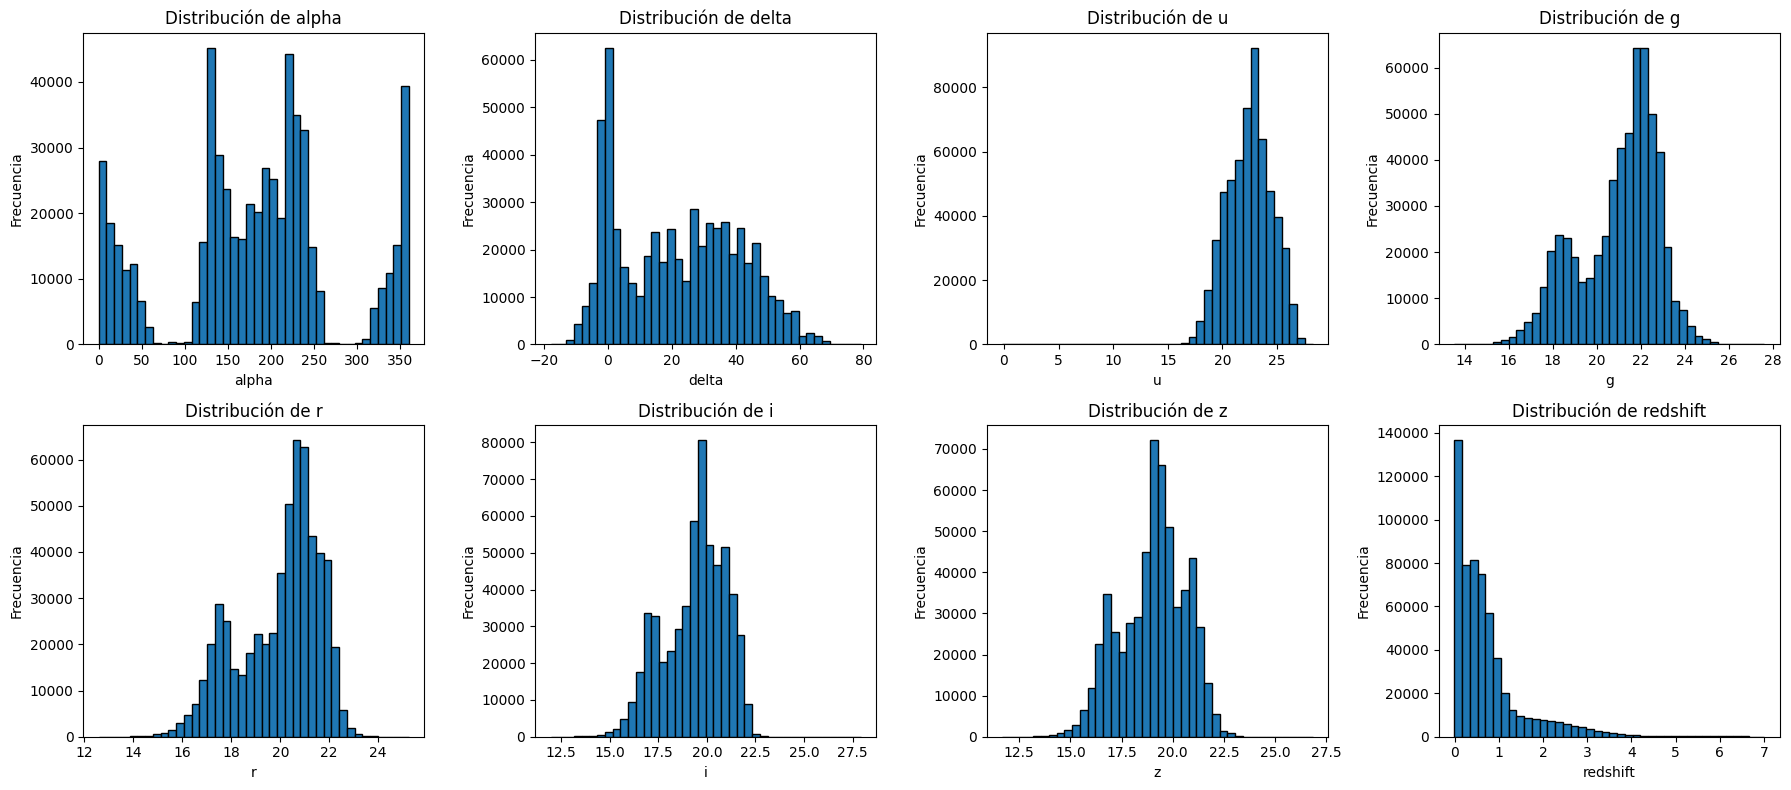

In [10]:
import math
import matplotlib.pyplot as plt

variables_numericas_eda = [
    "alpha", "delta", "u", "g", "r", "i", "z", "redshift"
]

n_columnas = 4
n_filas = math.ceil(len(variables_numericas_eda) / n_columnas)

fig, axes = plt.subplots(n_filas, n_columnas, figsize=(18, 8))
axes = axes.flatten()

for i, columna in enumerate(variables_numericas_eda):
    axes[i].hist(train[columna], bins=40, edgecolor="black")
    axes[i].set_title(f"Distribución de {columna}")
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel("Frecuencia")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Los histogramas permiten observar la forma de distribución de las variables numéricas. Las variables fotométricas u, g, r, i y z presentan concentraciones marcadas en rangos específicos, lo que indica que la mayoría de las observaciones astronómicas se agrupan en determinados niveles de magnitud. Este comportamiento es esperable en datos astronómicos, ya que las mediciones de brillo y color no se distribuyen de manera completamente uniforme.

La variable redshift muestra una distribución claramente asimétrica hacia la derecha. La mayor parte de los registros se concentra en valores bajos, pero existe una cola extensa hacia valores altos. Esto confirma lo observado en las estadísticas descriptivas: redshift presenta una asimetría positiva marcada y un 9,11% de observaciones clasificadas como atípicas bajo el criterio IQR. En este contexto, estos valores no deben eliminarse automáticamente, ya que pueden corresponder a objetos astronómicos físicamente válidos y aportar información relevante para distinguir entre GALAXY, QSO y STAR.

Las variables alpha y delta, asociadas a coordenadas espaciales, presentan una distribución más extendida, ya que representan posiciones de los objetos observados en el cielo. Estas variables pueden aportar información espacial, aunque su utilidad predictiva dependerá de si existen patrones de concentración por clase.

**2.4 Visualización de variables categóricas**

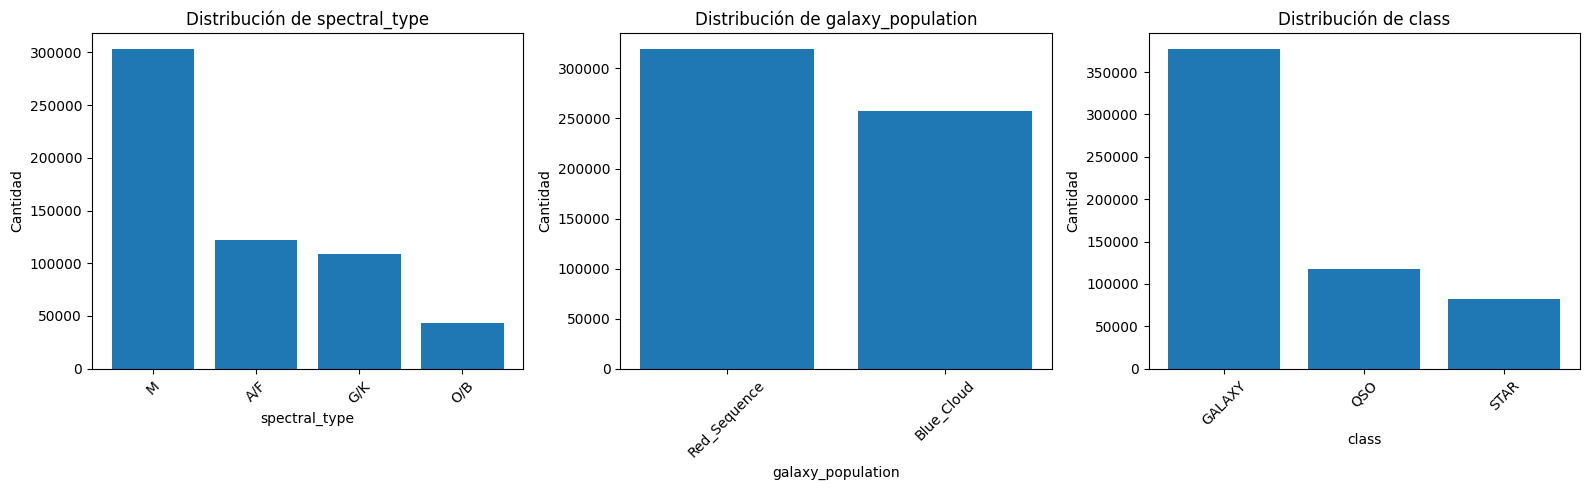

In [11]:
variables_categoricas_eda = [
    "spectral_type",
    "galaxy_population",
    "class"
]

n_columnas = 3
n_filas = math.ceil(len(variables_categoricas_eda) / n_columnas)

fig, axes = plt.subplots(n_filas, n_columnas, figsize=(16, 5))
axes = axes.flatten()

for i, columna in enumerate(variables_categoricas_eda):
    conteo = train[columna].value_counts()

    axes[i].bar(conteo.index.astype(str), conteo.values)
    axes[i].set_title(f"Distribución de {columna}")
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel("Cantidad")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Los gráficos de barras confirman que las variables categóricas presentan distribuciones desiguales. En spectral_type, la categoría M concentra más de la mitad de los registros, mientras que O/B es la menos frecuente. Esta diferencia puede influir en el aprendizaje del modelo, ya que las categorías con mayor presencia entregan más información durante el entrenamiento.

En galaxy_population existe una distribución relativamente equilibrada entre Red_Sequence y Blue_Cloud, lo que permite que ambas categorías estén representadas de forma suficiente en el modelo.

La variable objetivo class presenta un desbalance relevante: GALAXY es la clase dominante, seguida por QSO y STAR. Este punto es crítico porque, en un problema multiclase, un modelo podría alcanzar una exactitud aparentemente alta priorizando la clase mayoritaria. Por esta razón, se debe utilizar balanced accuracy como métrica principal y complementar con precisión, recall y F1-score por clase.

**2.5 Relación entre variables numéricas (Mapa de calor de correlaciones)**

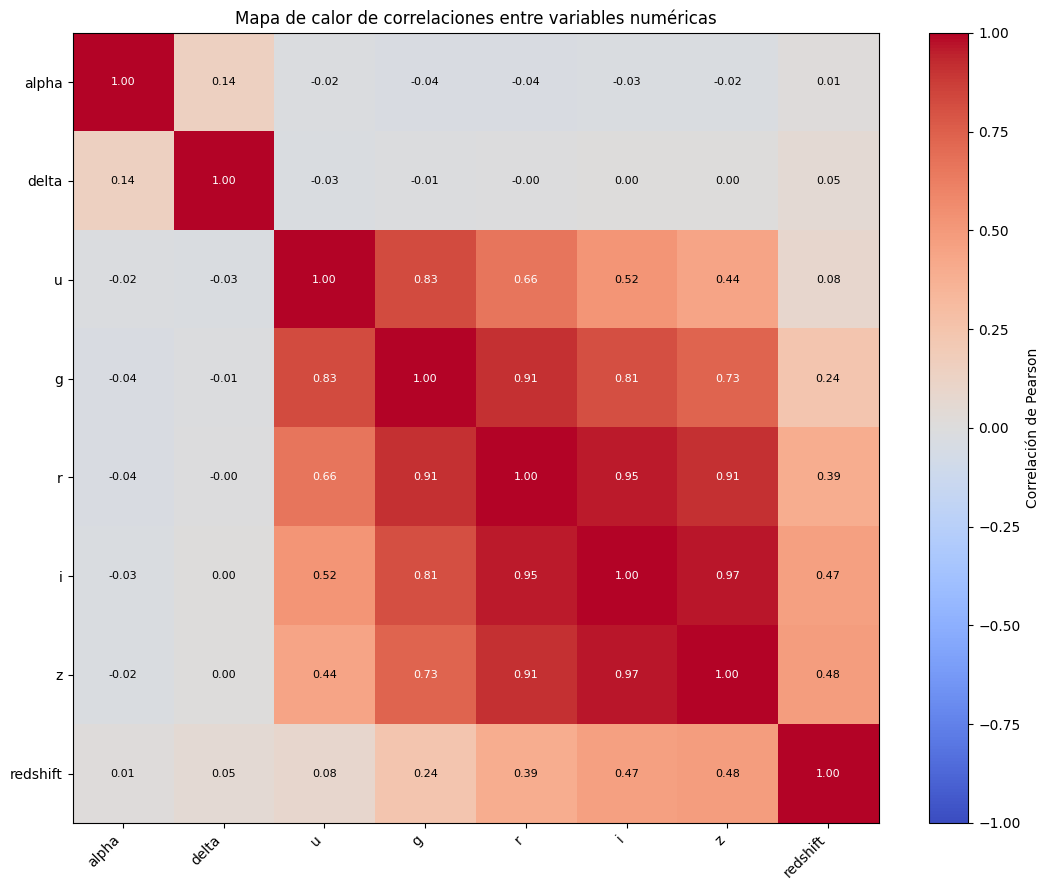

Correlaciones con redshift:


,Correlación con redshift
redshift,1.000000
z,0.480860
i,0.466575
r,0.390989
g,0.237447
u,0.078903
delta,0.053763
alpha,0.007989


In [14]:

correlacion_numerica = train[variables_numericas_eda].corr()

plt.figure(figsize=(11, 9))

imagen = plt.imshow(
    correlacion_numerica,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(imagen, label="Correlación de Pearson")

plt.xticks(
    range(len(correlacion_numerica.columns)),
    correlacion_numerica.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlacion_numerica.index)),
    correlacion_numerica.index
)

# Mostrar el valor exacto dentro de cada celda
for fila in range(len(correlacion_numerica.index)):
    for columna in range(len(correlacion_numerica.columns)):
        valor = correlacion_numerica.iloc[fila, columna]

        plt.text(
            columna,
            fila,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if abs(valor) > 0.55 else "black"
        )

plt.title("Mapa de calor de correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()

print("Correlaciones con redshift:")
display(
    correlacion_numerica["redshift"]
    .sort_values(ascending=False)
    .to_frame("Correlación con redshift")
)

El mapa de correlaciones evidencia una estructura clara entre las variables fotométricas. Las bandas u, g, r, i y z presentan correlaciones positivas altas, destacando i-z (0,97), r-i (0,95), g-r (0,91) y r-z (0,91). Esto es coherente con que estas variables representan mediciones de brillo del mismo objeto en distintas bandas espectrales.

La variable redshift muestra correlaciones moderadas con las bandas z (0,48), i (0,47) y r (0,39), mientras que su asociación con u (0,08), alpha (0,01) y delta (0,05) es prácticamente nula. Esto indica que redshift contiene información complementaria a las magnitudes fotométricas y puede resultar especialmente útil para separar objetos con distinta distancia cosmológica, como GALAXY y QSO.

Las coordenadas alpha y delta presentan correlaciones muy bajas con las variables fotométricas, por lo que su valor predictivo no puede inferirse solo desde relaciones lineales. Se conservarán inicialmente y su contribución será evaluada mediante el desempeño comparativo de los modelos y la importancia de variables.

La presencia de multicolinealidad entre las bandas fotométricas no justifica eliminarlas de forma automática. En modelos basados en árboles, como Árbol de Decisión, Random Forest, XGBoost y LightGBM, este fenómeno suele ser manejable. En cambio, para Regresión Logística, KNN y SVM será indispensable aplicar escalamiento dentro de un pipeline para evitar que las diferencias de escala afecten el entrenamiento.

**2.6 Diagramas de dispersión por clase (Diagramas de dispersión por clase)**

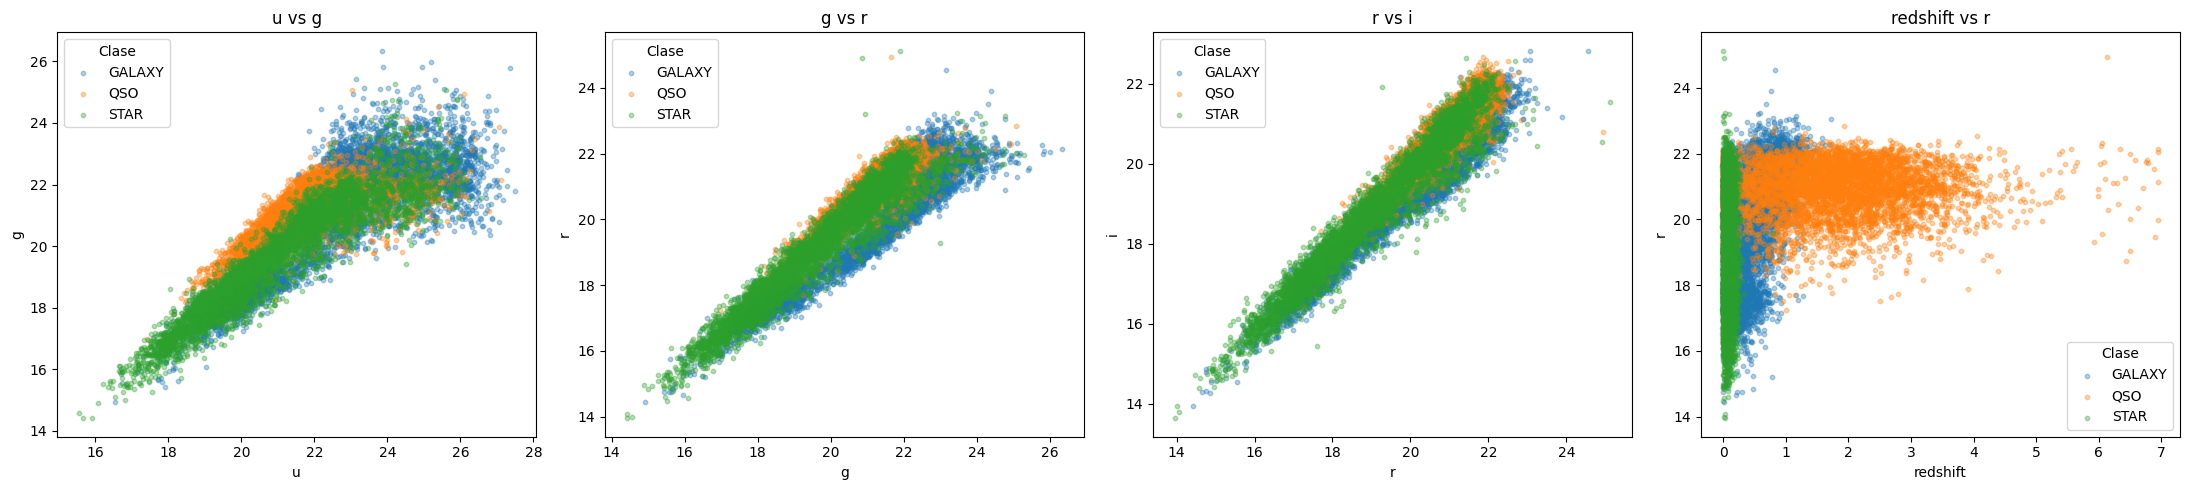

Tamaño de la muestra utilizada: (15000, 12)

Distribución de clases en la muestra:


,Cantidad
class,
GALAXY,5000
QSO,5000
STAR,5000


In [13]:
# Muestra estratificada: mantiene la proporción de GALAXY, QSO y STAR
muestra_grafico = (
    train.groupby("class", group_keys=False)
    .apply(
        lambda grupo: grupo.sample(
            n=min(5000, len(grupo)),
            random_state=42
        )
    )
)

pares_dispersion = [
    ("u", "g"),
    ("g", "r"),
    ("r", "i"),
    ("redshift", "r")
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (x, y) in zip(axes, pares_dispersion):
    for clase in sorted(muestra_grafico["class"].unique()):
        datos_clase = muestra_grafico[muestra_grafico["class"] == clase]

        ax.scatter(
            datos_clase[x],
            datos_clase[y],
            alpha=0.35,
            s=10,
            label=clase
        )

    ax.set_title(f"{x} vs {y}")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(title="Clase")

plt.tight_layout()
plt.show()

print("Tamaño de la muestra utilizada:", muestra_grafico.shape)
print("\nDistribución de clases en la muestra:")
display(
    muestra_grafico["class"]
    .value_counts()
    .to_frame("Cantidad")
)

Los diagramas de dispersión permiten evaluar si existen patrones visuales de separación entre GALAXY, QSO y STAR. Las combinaciones entre las bandas fotométricas u, g, r e i muestran agrupamientos y relaciones no lineales, lo que justifica utilizar modelos capaces de aprender fronteras de decisión complejas.

La relación entre redshift y la magnitud r es particularmente importante. Los cuásares suelen exhibir valores de redshift relativamente mayores, debido a que corresponden a objetos muy distantes. En contraste, estrellas y una parte importante de las galaxias tienden a concentrarse en rangos menores de redshift.

La superposición parcial entre clases confirma que el problema no puede resolverse de forma confiable mediante una única regla simple. Por ello, se compararán modelos lineales, basados en distancia y basados en árboles, evaluando no solo el rendimiento global, sino también la capacidad de clasificar correctamente cada clase.

# **3. Preprocesamiento de datos**

**3.1 Definición de variables predictoras y variable objetivo**

In [15]:
# ============================================================
# Definir X e y
# Se elimina "id" porque es un identificador único y no aporta
# información científica sobre la clase del objeto astronómico.
X = train.drop(columns=["id", "class"])
y = train["class"]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

print("\nVariables predictoras:")
print(X.columns.tolist())

print("\nDistribución de la variable objetivo:")
display(
    y.value_counts()
    .to_frame("Cantidad")
    .assign(Porcentaje=lambda tabla: (tabla["Cantidad"] / len(y) * 100).round(2))
)

Dimensión de X: (577347, 10)
Dimensión de y: (577347,)

Variables predictoras:
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population']

Distribución de la variable objetivo:


,Cantidad,Porcentaje
class,,
GALAXY,377480,65.38
QSO,117143,20.29
STAR,82724,14.33


La variable `id` se excluye del modelamiento porque es un identificador único asignado a cada observación. Mantenerla podría introducir patrones artificiales sin significado astronómico y afectar la capacidad de generalización del modelo.

Las variables predictoras incluyen ocho atributos numéricos: alpha, delta, u, g, r, i, z y redshift; además de dos variables categóricas: spectral_type y galaxy_population. La variable objetivo corresponde a class, con tres categorías: GALAXY, QSO y STAR.

**3.2 División estratificada en entrenamiento y prueba**

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Dimensión X_train:", X_train.shape)
print("Dimensión X_test:", X_test.shape)

print("\nDistribución de clases en entrenamiento (%):")
display((y_train.value_counts(normalize=True) * 100).round(2).to_frame("Porcentaje"))

print("\nDistribución de clases en prueba (%):")
display((y_test.value_counts(normalize=True) * 100).round(2).to_frame("Porcentaje"))

Dimensión X_train: (461877, 10)
Dimensión X_test: (115470, 10)

Distribución de clases en entrenamiento (%):


,Porcentaje
class,
GALAXY,65.38
QSO,20.29
STAR,14.33



Distribución de clases en prueba (%):


,Porcentaje
class,
GALAXY,65.38
QSO,20.29
STAR,14.33


Se utiliza una división estratificada de 80% para entrenamiento y 20% para prueba. La estratificación conserva la proporción de GALAXY, QSO y STAR en ambos conjuntos, evitando que la clase mayoritaria condicione artificialmente la evaluación.

El conjunto de prueba permanecerá aislado durante la selección y ajuste de modelos. De esta forma, las métricas finales reflejarán la capacidad de generalización sobre observaciones no utilizadas durante el entrenamiento.

**3.3 Construcción del pipeline de preprocesamiento (Definir variables numéricas y categóricas)**

In [17]:
variables_numericas_modelo = [
    "alpha",
    "delta",
    "u",
    "g",
    "r",
    "i",
    "z",
    "redshift"
]

variables_categoricas_modelo = [
    "spectral_type",
    "galaxy_population"
]

print("Variables numéricas:", variables_numericas_modelo)
print("Variables categóricas:", variables_categoricas_modelo)

Variables numéricas: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Variables categóricas: ['spectral_type', 'galaxy_population']


**3.4 Preprocesador reusable para todos los modelos**

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

transformador_numerico = Pipeline(steps=[
    ("escalador", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            transformador_numerico,
            variables_numericas_modelo
        ),
        (
            "categoricas",
            transformador_categorico,
            variables_categoricas_modelo
        )
    ]
)

preprocesador

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('escalador',
                                                  StandardScaler())]),
                                 ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z',
                                  'redshift']),
                                ('categoricas',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['spectral_type', 'galaxy_population'])])

Las variables numéricas se transforman mediante StandardScaler, que centra los datos alrededor de cero y los ajusta a una desviación estándar unitaria. Este paso es esencial para KNN, Regresión Logística y SVM, debido a que estos algoritmos son sensibles a la escala de las variables.

Las variables categóricas spectral_type y galaxy_population se codifican mediante One-Hot Encoding. Esta técnica genera columnas binarias para cada categoría y evita imponer un orden artificial entre sus valores.

El preprocesamiento se encapsula en un Pipeline. Esto asegura que las transformaciones se aprendan únicamente desde el conjunto de entrenamiento y luego se apliquen al conjunto de prueba, evitando fuga de información.

**3.5 Verificación de la transformación (Verificar dimensiones después del preprocesamiento)**

In [19]:
X_train_transformado = preprocesador.fit_transform(X_train)
X_test_transformado = preprocesador.transform(X_test)

print("Dimensión de X_train transformado:", X_train_transformado.shape)
print("Dimensión de X_test transformado:", X_test_transformado.shape)

nombres_variables_transformadas = preprocesador.get_feature_names_out()

print("\nCantidad de variables finales:", len(nombres_variables_transformadas))
print("\nVariables transformadas:")
print(nombres_variables_transformadas)

Dimensión de X_train transformado: (461877, 14)
Dimensión de X_test transformado: (115470, 14)

Cantidad de variables finales: 14

Variables transformadas:
['numericas__alpha' 'numericas__delta' 'numericas__u' 'numericas__g'
 'numericas__r' 'numericas__i' 'numericas__z' 'numericas__redshift'
 'categoricas__spectral_type_A/F' 'categoricas__spectral_type_G/K'
 'categoricas__spectral_type_M' 'categoricas__spectral_type_O/B'
 'categoricas__galaxy_population_Blue_Cloud'
 'categoricas__galaxy_population_Red_Sequence']


# **4. Benchmark inicial de modelos de clasificación**

El objetivo del benchmark es comparar modelos con supuestos de aprendizaje diferentes: un modelo lineal, un modelo basado en margen, un árbol de decisión y dos algoritmos de boosting. Debido al tamaño del conjunto de entrenamiento, la validación cruzada se realizará sobre una muestra estratificada y balanceada. Esto permite obtener una comparación computacionalmente eficiente, evitando que la clase GALAXY domine artificialmente el resultado.

La métrica principal será balanced accuracy, ya que asigna la misma importancia a GALAXY, QSO y STAR, independientemente de su frecuencia original. Como métricas complementarias se utilizarán F1-score macro y precisión global.

**4.1 Construcción de muestra estratificada para validación cruzada (Muestra estratificada y balanceada para benchmark)**

In [20]:
from sklearn.utils import resample

# Se toman 20.000 registros por clase.
# Esto mantiene representación equilibrada y reduce el costo computacional.
tamano_por_clase = 20000

indices_benchmark = []

for clase in y_train.unique():
    indices_clase = y_train[y_train == clase].index

    muestra_clase = resample(
        indices_clase,
        replace=False,
        n_samples=tamano_por_clase,
        random_state=42
    )

    indices_benchmark.extend(muestra_clase)

X_benchmark = X_train.loc[indices_benchmark]
y_benchmark = y_train.loc[indices_benchmark]

print("Dimensión de la muestra para benchmark:", X_benchmark.shape)

display(
    y_benchmark.value_counts()
    .to_frame("Cantidad")
    .assign(
        Porcentaje=lambda tabla: (
            tabla["Cantidad"] / len(y_benchmark) * 100
        ).round(2)
    )
)

Dimensión de la muestra para benchmark: (60000, 10)


,Cantidad,Porcentaje
class,,
STAR,20000,33.33
GALAXY,20000,33.33
QSO,20000,33.33


**4.2 Definición de modelos candidatos**

In [21]:
# Importar modelos para el benchmark
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

**4.3 Crear pipelines de modelos**

In [22]:
modelos_benchmark = {
    "Regresión Logística": Pipeline(steps=[
        ("preprocesador", preprocesador),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                n_jobs=-1,
                random_state=42
            )
        )
    ]),

    "SVM Lineal": Pipeline(steps=[
        ("preprocesador", preprocesador),
        (
            "modelo",
            LinearSVC(
                class_weight="balanced",
                dual="auto",
                max_iter=5000,
                random_state=42
            )
        )
    ]),

    "Árbol de Decisión": Pipeline(steps=[
        ("preprocesador", preprocesador),
        (
            "modelo",
            DecisionTreeClassifier(
                max_depth=20,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "XGBoost": Pipeline(steps=[
        ("preprocesador", preprocesador),
        (
            "modelo",
            XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                n_estimators=200,
                learning_rate=0.10,
                max_depth=8,
                subsample=0.80,
                colsample_bytree=0.80,
                eval_metric="mlogloss",
                n_jobs=-1,
                random_state=42
            )
        )
    ]),

    "LightGBM": Pipeline(steps=[
        ("preprocesador", preprocesador),
        (
            "modelo",
            LGBMClassifier(
                objective="multiclass",
                num_class=3,
                n_estimators=200,
                learning_rate=0.10,
                num_leaves=31,
                subsample=0.80,
                colsample_bytree=0.80,
                n_jobs=-1,
                random_state=42,
                verbosity=-1
            )
        )
    ])
}

print("Modelos definidos:")
for nombre in modelos_benchmark:
    print("-", nombre)

Modelos definidos:
- Regresión Logística
- SVM Lineal
- Árbol de Decisión
- XGBoost
- LightGBM


Se seleccionan cinco algoritmos con mecanismos de aprendizaje distintos. La Regresión Logística representa un modelo lineal interpretable; SVM Lineal busca fronteras de separación de máximo margen; el Árbol de Decisión incorpora reglas no lineales; XGBoost y LightGBM utilizan boosting para combinar múltiples árboles débiles y capturar relaciones complejas entre variables.

No se incorpora KNN en el benchmark principal debido al alto costo computacional de calcular distancias entre decenas de miles de observaciones durante la predicción. En un conjunto de esta magnitud, su tiempo de ejecución crece considerablemente y resulta menos eficiente que los modelos seleccionados.

**4.4 Codificación de la variable objetivo**

In [24]:
from sklearn.preprocessing import LabelEncoder

codificador_clases = LabelEncoder()

y_train_codificado = codificador_clases.fit_transform(y_train)
y_test_codificado = codificador_clases.transform(y_test)

print("Clases originales:", codificador_clases.classes_)

for codigo, clase in enumerate(codificador_clases.classes_):
    print(f"{codigo}: {clase}")

Clases originales: ['GALAXY' 'QSO' 'STAR']
0: GALAXY
1: QSO
2: STAR


In [26]:
y_benchmark_codificado = codificador_clases.transform(y_benchmark)

print("\nClases presentes en benchmark:", np.unique(y_benchmark_codificado))


Clases presentes en benchmark: [0 1 2]


**4.5 Validación cruzada estratificada**

In [25]:
# Configurar validación cruzada
from sklearn.model_selection import StratifiedKFold, cross_validate

validacion_cruzada = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

metricas_cv = {
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "accuracy": "accuracy"
}

**4.6 Ejecutar validación cruzada para los cinco modelos**

In [27]:
resultados_benchmark = []

for nombre, pipeline_modelo in modelos_benchmark.items():

    print(f"\nEvaluando: {nombre}")

    resultado_cv = cross_validate(
        estimator=pipeline_modelo,
        X=X_benchmark,
        y=y_benchmark_codificado,
        cv=validacion_cruzada,
        scoring=metricas_cv,
        n_jobs=1,
        return_train_score=False
    )

    resultados_benchmark.append({
        "Modelo": nombre,
        "Balanced Accuracy promedio": resultado_cv["test_balanced_accuracy"].mean(),
        "Balanced Accuracy desviación": resultado_cv["test_balanced_accuracy"].std(),
        "F1 Macro promedio": resultado_cv["test_f1_macro"].mean(),
        "Accuracy promedio": resultado_cv["test_accuracy"].mean()
    })

tabla_benchmark = (
    pd.DataFrame(resultados_benchmark)
    .sort_values(by="Balanced Accuracy promedio", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

print("\nBenchmark finalizado.")
display(tabla_benchmark)


Evaluando: Regresión Logística

Evaluando: SVM Lineal

Evaluando: Árbol de Decisión

Evaluando: XGBoost

Evaluando: LightGBM

Benchmark finalizado.


,Modelo,Balanced Accuracy promedio,Balanced Accuracy desviación,F1 Macro promedio,Accuracy promedio
0,XGBoost,0.9575,0.0017,0.9575,0.9575
1,LightGBM,0.9570,0.0019,0.9570,0.9570
2,Árbol de Decisión,0.9349,0.0013,0.9350,0.9349
3,Regresión Logística,0.9102,0.0008,0.9102,0.9102
4,SVM Lineal,0.8963,0.0013,0.8963,0.8963


XGBoost obtuvo el mejor rendimiento inicial, con una balanced accuracy de 95,75%, seguido muy de cerca por LightGBM con 95,70%. La diferencia entre ambos es mínima, por lo que ambos modelos se consideran candidatos adecuados para la etapa de optimización.

El Árbol de Decisión alcanzó un desempeño competitivo (93,49%), aunque inferior a los métodos de boosting. Esto sugiere que el problema contiene relaciones no lineales que pueden ser capturadas con mayor precisión mediante conjuntos de árboles secuenciales.

La Regresión Logística y SVM Lineal obtuvieron resultados inferiores, aunque todavía elevados. Esto indica que las variables presentan cierta separabilidad lineal, pero los modelos basados en boosting aprovechan mejor interacciones y fronteras de decisión más complejas entre GALAXY, QSO y STAR.

La baja desviación estándar observada en los cinco modelos indica que su desempeño es estable entre los tres folds de validación cruzada. Debido al desbalance de clases, la balanced accuracy y el F1 macro se priorizan sobre la accuracy convencional, pues evalúan de manera más equilibrada la capacidad de clasificación de GALAXY, QSO y STAR.

**4.7 Visualización comparativa del benchmark**

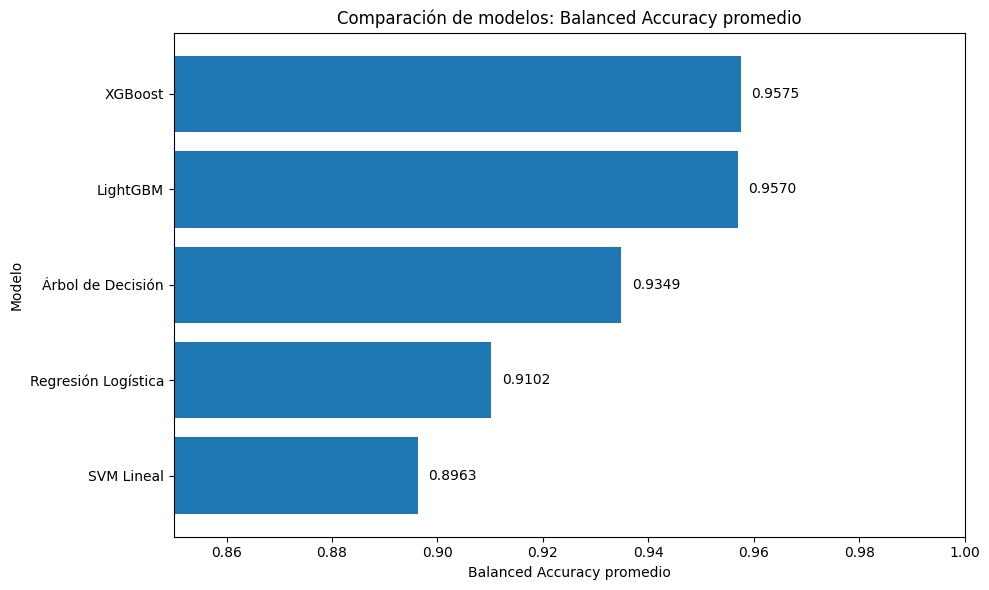

In [28]:
tabla_grafico = tabla_benchmark.sort_values(
    by="Balanced Accuracy promedio",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    tabla_grafico["Modelo"],
    tabla_grafico["Balanced Accuracy promedio"]
)

plt.title("Comparación de modelos: Balanced Accuracy promedio")
plt.xlabel("Balanced Accuracy promedio")
plt.ylabel("Modelo")

for indice, valor in enumerate(
    tabla_grafico["Balanced Accuracy promedio"]
):
    plt.text(
        valor + 0.002,
        indice,
        f"{valor:.4f}",
        va="center"
    )

plt.xlim(0.85, 1.00)
plt.tight_layout()
plt.show()

El benchmark confirma que XGBoost y LightGBM son los modelos con mejor capacidad predictiva, ambos con una balanced accuracy cercana al 96%. La diferencia entre ellos es de solo 0,05 puntos porcentuales, por lo que no es estadísticamente prudente declarar un ganador definitivo solo con este resultado inicial.

El Árbol de Decisión supera a los modelos lineales, reforzando la existencia de relaciones no lineales entre las variables fotométricas y la clase astronómica. Sin embargo, los métodos de boosting alcanzan un desempeño superior al combinar múltiples árboles y reducir progresivamente el error de clasificación.

Para la siguiente etapa se seleccionan XGBoost y LightGBM como modelos finalistas. Se optimizarán sus hiperparámetros mediante validación cruzada, priorizando balanced accuracy y F1 macro para mantener un desempeño equilibrado entre GALAXY, QSO y STAR.

# **5. Optimización de hiperparámetros**

**5.1 Configuración de la búsqueda de hiperparámetros**

In [29]:
# Crear muestra estratificada para optimización
from sklearn.model_selection import train_test_split

X_optimizacion, _, y_optimizacion, _ = train_test_split(
    X_train,
    y_train_codificado,
    train_size=60000,
    stratify=y_train_codificado,
    random_state=42
)

print("Dimensión de la muestra para optimización:", X_optimizacion.shape)

distribucion_optimizacion = (
    pd.Series(y_optimizacion)
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nDistribución porcentual de clases en la muestra:")
for codigo, porcentaje in distribucion_optimizacion.items():
    print(f"{codificador_clases.inverse_transform([codigo])[0]}: {porcentaje}%")

Dimensión de la muestra para optimización: (60000, 10)

Distribución porcentual de clases en la muestra:
GALAXY: 65.38%
QSO: 20.29%
STAR: 14.33%


La muestra de optimización se construye mediante muestreo estratificado para preservar la distribución original de clases. Esto permite reducir el costo computacional de la búsqueda de hiperparámetros sin alterar artificialmente la representación relativa de GALAXY, QSO y STAR.

**5.2 Configuración de RandomizedSearchCV para XGBoost**

In [30]:
# Optimización de XGBoost mediante RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

parametros_xgboost = {
    "modelo__n_estimators": [150, 200, 250],
    "modelo__max_depth": [4, 6, 8],
    "modelo__learning_rate": [0.05, 0.10, 0.15],
    "modelo__subsample": [0.80, 0.90, 1.00],
    "modelo__colsample_bytree": [0.80, 0.90, 1.00],
    "modelo__min_child_weight": [1, 3, 5]
}

busqueda_xgboost = RandomizedSearchCV(
    estimator=modelos_benchmark["XGBoost"],
    param_distributions=parametros_xgboost,
    n_iter=12,
    scoring="balanced_accuracy",
    cv=validacion_cruzada,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    return_train_score=True
)

print("RandomizedSearchCV para XGBoost configurado.")
print("Combinaciones aleatorias a evaluar:", 12)
print("Validación cruzada:", 3, "folds")

RandomizedSearchCV para XGBoost configurado.
Combinaciones aleatorias a evaluar: 12
Validación cruzada: 3 folds


**5.3 Ejecución de optimización de XGBoost**

In [31]:
# Ejecutar optimización de XGBoost

busqueda_xgboost.fit(
    X_optimizacion,
    y_optimizacion
)

print("\nOptimización de XGBoost finalizada.")
print("Mejor Balanced Accuracy CV:", round(busqueda_xgboost.best_score_, 4))

print("\nMejores hiperparámetros:")
for parametro, valor in busqueda_xgboost.best_params_.items():
    print(f"{parametro}: {valor}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Optimización de XGBoost finalizada.
Mejor Balanced Accuracy CV: 0.9461

Mejores hiperparámetros:
modelo__subsample: 0.9
modelo__n_estimators: 200
modelo__min_child_weight: 1
modelo__max_depth: 6
modelo__learning_rate: 0.1
modelo__colsample_bytree: 0.9


**5.4 Comparación de XGBoost base versus optimizado**

In [32]:
xgboost_base = modelos_benchmark["XGBoost"]

score_xgboost_base = cross_validate(
    estimator=xgboost_base,
    X=X_optimizacion,
    y=y_optimizacion,
    cv=validacion_cruzada,
    scoring="balanced_accuracy",
    n_jobs=-1
)["test_score"]

score_xgboost_optimizado = cross_validate(
    estimator=busqueda_xgboost.best_estimator_,
    X=X_optimizacion,
    y=y_optimizacion,
    cv=validacion_cruzada,
    scoring="balanced_accuracy",
    n_jobs=-1
)["test_score"]

comparacion_xgboost = pd.DataFrame({
    "Modelo": ["XGBoost base", "XGBoost optimizado"],
    "Balanced Accuracy promedio": [
        score_xgboost_base.mean(),
        score_xgboost_optimizado.mean()
    ],
    "Desviación estándar": [
        score_xgboost_base.std(),
        score_xgboost_optimizado.std()
    ]
}).round(4)

comparacion_xgboost["Diferencia vs. base"] = [
    0,
    round(
        comparacion_xgboost.loc[1, "Balanced Accuracy promedio"]
        - comparacion_xgboost.loc[0, "Balanced Accuracy promedio"],
        4
    )
]

display(comparacion_xgboost)

,Modelo,Balanced Accuracy promedio,Desviación estándar,Diferencia vs. base
0,XGBoost base,0.9452,0.0018,0.0000
1,XGBoost optimizado,0.9461,0.0006,0.0009


La optimización de XGBoost elevó la balanced accuracy promedio desde 0,9452 hasta 0,9461. Aunque la mejora absoluta es reducida, el modelo optimizado presenta una menor desviación estándar entre los folds de validación cruzada, lo que indica un comportamiento más estable. Por ello, se conservará XGBoost optimizado para su evaluación final sobre el conjunto de prueba.

**5.5 Configuración de RandomizedSearchCV para LightGBM**

In [33]:
parametros_lightgbm = {
    "modelo__n_estimators": [150, 200, 250],
    "modelo__learning_rate": [0.03, 0.05, 0.10],
    "modelo__num_leaves": [15, 31, 63],
    "modelo__max_depth": [-1, 8, 12],
    "modelo__min_child_samples": [10, 20, 30],
    "modelo__subsample": [0.80, 0.90, 1.00],
    "modelo__colsample_bytree": [0.80, 0.90, 1.00]
}

busqueda_lightgbm = RandomizedSearchCV(
    estimator=modelos_benchmark["LightGBM"],
    param_distributions=parametros_lightgbm,
    n_iter=12,
    scoring="balanced_accuracy",
    cv=validacion_cruzada,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    return_train_score=True
)

print("RandomizedSearchCV para LightGBM configurado.")
print("Combinaciones aleatorias a evaluar:", 12)
print("Validación cruzada:", 3, "folds")

RandomizedSearchCV para LightGBM configurado.
Combinaciones aleatorias a evaluar: 12
Validación cruzada: 3 folds


**5.6 Ejecución de optimización de LightGBM**

In [34]:
busqueda_lightgbm.fit(
    X_optimizacion,
    y_optimizacion
)

print("\nOptimización de LightGBM finalizada.")
print("Mejor Balanced Accuracy CV:", round(busqueda_lightgbm.best_score_, 4))

print("\nMejores hiperparámetros:")
for parametro, valor in busqueda_lightgbm.best_params_.items():
    print(f"{parametro}: {valor}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Optimización de LightGBM finalizada.
Mejor Balanced Accuracy CV: 0.946

Mejores hiperparámetros:
modelo__subsample: 1.0
modelo__num_leaves: 31
modelo__n_estimators: 250
modelo__min_child_samples: 10
modelo__max_depth: -1
modelo__learning_rate: 0.1
modelo__colsample_bytree: 0.9


El resultado es prácticamente igual al XGBoost optimizado (0,9461). Ahora debemos compararlo con el LightGBM base usando exactamente la misma muestra estratificada de 60.000 registros.

**5.7 Comparación de LightGBM base versus optimizado**

In [35]:
lightgbm_base = modelos_benchmark["LightGBM"]

score_lightgbm_base = cross_validate(
    estimator=lightgbm_base,
    X=X_optimizacion,
    y=y_optimizacion,
    cv=validacion_cruzada,
    scoring="balanced_accuracy",
    n_jobs=-1
)["test_score"]

score_lightgbm_optimizado = cross_validate(
    estimator=busqueda_lightgbm.best_estimator_,
    X=X_optimizacion,
    y=y_optimizacion,
    cv=validacion_cruzada,
    scoring="balanced_accuracy",
    n_jobs=-1
)["test_score"]

comparacion_lightgbm = pd.DataFrame({
    "Modelo": ["LightGBM base", "LightGBM optimizado"],
    "Balanced Accuracy promedio": [
        score_lightgbm_base.mean(),
        score_lightgbm_optimizado.mean()
    ],
    "Desviación estándar": [
        score_lightgbm_base.std(),
        score_lightgbm_optimizado.std()
    ]
}).round(4)

comparacion_lightgbm["Diferencia vs. base"] = [
    0,
    round(
        comparacion_lightgbm.loc[1, "Balanced Accuracy promedio"]
        - comparacion_lightgbm.loc[0, "Balanced Accuracy promedio"],
        4
    )
]

display(comparacion_lightgbm)

,Modelo,Balanced Accuracy promedio,Desviación estándar,Diferencia vs. base
0,LightGBM base,0.9459,0.0012,0.0000
1,LightGBM optimizado,0.9460,0.0021,0.0001


La búsqueda de hiperparámetros de LightGBM produjo una mejora marginal de 0,0001 en balanced accuracy, equivalente a 0,01 puntos porcentuales. Dado que esta diferencia es prácticamente nula y la desviación estándar aumentó, se mantendrá la configuración base de LightGBM. Esto evita incorporar complejidad sin una ganancia comprobable de desempeño.

# **6. Evaluación final de modelos finalistas**

**6.1 Entrenamiento final con todo el conjunto de entrenamiento**

In [36]:
xgboost_final = busqueda_xgboost.best_estimator_
lightgbm_final = modelos_benchmark["LightGBM"]

xgboost_final.fit(X_train, y_train_codificado)
lightgbm_final.fit(X_train, y_train_codificado)

print("XGBoost optimizado entrenado con todo X_train.")
print("LightGBM base entrenado con todo X_train.")

XGBoost optimizado entrenado con todo X_train.
LightGBM base entrenado con todo X_train.


**6.2 Evaluación comparativa en el conjunto de prueba**

In [37]:
from sklearn.metrics import balanced_accuracy_score, f1_score, accuracy_score

modelos_finalistas = {
    "XGBoost optimizado": xgboost_final,
    "LightGBM base": lightgbm_final
}

resultados_finales = []

for nombre, modelo in modelos_finalistas.items():
    predicciones = modelo.predict(X_test)

    resultados_finales.append({
        "Modelo": nombre,
        "Balanced Accuracy": balanced_accuracy_score(
            y_test_codificado,
            predicciones
        ),
        "F1 Macro": f1_score(
            y_test_codificado,
            predicciones,
            average="macro"
        ),
        "Accuracy": accuracy_score(
            y_test_codificado,
            predicciones
        )
    })

tabla_finalistas = (
    pd.DataFrame(resultados_finales)
    .sort_values(by="Balanced Accuracy", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

display(tabla_finalistas)

,Modelo,Balanced Accuracy,F1 Macro,Accuracy
0,LightGBM base,0.951,0.9518,0.9644
1,XGBoost optimizado,0.950,0.9512,0.9641


La evaluación final sobre el conjunto de prueba reservado confirma que LightGBM base presenta el mejor desempeño global. Alcanzó una balanced accuracy de 0,9510, superior al 0,9500 obtenido por XGBoost optimizado. También obtuvo mejores resultados en F1 Macro y accuracy. Por tanto, se selecciona LightGBM base como modelo definitivo para generar las predicciones de la competencia Kaggle.

**6.3 Matriz de confusión y reporte de clasificación del modelo final**

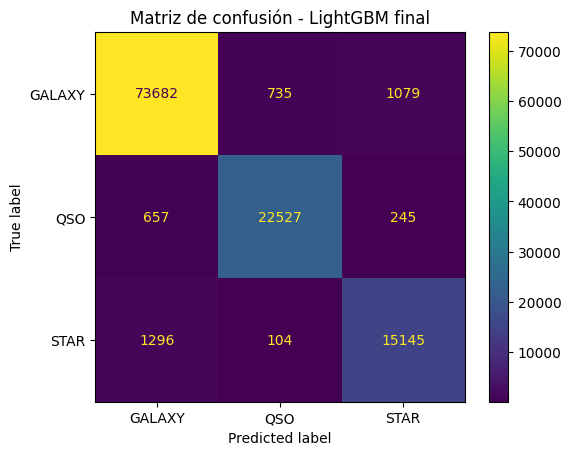

Reporte de clasificación:

              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98     75496
         QSO       0.96      0.96      0.96     23429
        STAR       0.92      0.92      0.92     16545

    accuracy                           0.96    115470
   macro avg       0.95      0.95      0.95    115470
weighted avg       0.96      0.96      0.96    115470



In [38]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

predicciones_finales = lightgbm_final.predict(X_test)

matriz_final = confusion_matrix(
    y_test_codificado,
    predicciones_finales
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_final,
    display_labels=codificador_clases.classes_
)

disp.plot()
plt.title("Matriz de confusión - LightGBM final")
plt.show()

print("Reporte de clasificación:\n")
print(
    classification_report(
        y_test_codificado,
        predicciones_finales,
        target_names=codificador_clases.classes_
    )
)

La matriz de confusión muestra un desempeño consistente en las tres clases astronómicas. GALAXY presenta el mayor recall, mientras que QSO mantiene un equilibrio alto entre precisión y recall. La clase STAR alcanza un desempeño menor, con parte de sus observaciones clasificadas como GALAXY, lo que sugiere una zona de solapamiento entre ambas clases. Sin embargo, el F1-score macro de 0,95 confirma que el modelo no depende únicamente de la clase mayoritaria y mantiene una capacidad predictiva equilibrada.

# **7. Generación de predicciones para Kaggle**

**7.1 Entrenamiento del modelo final con todos los datos disponibles**

In [39]:
modelo_final_kaggle = modelos_benchmark["LightGBM"]

modelo_final_kaggle.fit(
    X,
    codificador_clases.transform(y)
)

print("Modelo LightGBM final entrenado con todos los registros disponibles.")

Modelo LightGBM final entrenado con todos los registros disponibles.


**7.2 Generación de predicciones sobre test.csv**

In [40]:
X_kaggle_test = test.drop(columns=["id"])

predicciones_test_codificadas = modelo_final_kaggle.predict(X_kaggle_test)

predicciones_test = codificador_clases.inverse_transform(
    predicciones_test_codificadas
)

print("Cantidad de predicciones generadas:", len(predicciones_test))
print("Clases predichas:")
display(pd.Series(predicciones_test).value_counts())

Cantidad de predicciones generadas: 247435
Clases predichas:


,count
GALAXY,162032
QSO,50072
STAR,35331


**7.3 Creación y validación del archivo submission.csv**

In [41]:
submission = pd.DataFrame({
    "id": test["id"],
    "class": predicciones_test
})

# Validaciones del formato solicitado por Kaggle
assert submission.shape[0] == test.shape[0], "La cantidad de filas no coincide con test.csv"
assert submission.columns.tolist() == sample_submission.columns.tolist(), "Las columnas no coinciden con sample_submission.csv"
assert submission["id"].equals(test["id"]), "Los identificadores no coinciden con test.csv"
assert submission["class"].isna().sum() == 0, "Existen predicciones faltantes"

# Guardar archivo
RUTA_SUBMISSION_FINAL = "/content/drive/MyDrive/submission_lightgbm.csv"
submission.to_csv(RUTA_SUBMISSION_FINAL, index=False)

print("Archivo creado correctamente.")
print("Ruta:", RUTA_SUBMISSION_FINAL)
print("Dimensión:", submission.shape)

display(submission.head())

Archivo creado correctamente.
Ruta: /content/drive/MyDrive/submission_lightgbm.csv
Dimensión: (247435, 2)


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


Se generó el archivo submission_lightgbm.csv con 247.435 predicciones, utilizando el identificador original de cada observación y la clase predicha por LightGBM. Se verificó que la estructura del archivo coincide con sample_submission.csv, que no existen valores faltantes y que los identificadores mantienen el mismo orden que el conjunto de prueba.

# **8. Conclusiones**

Se desarrolló un flujo completo de clasificación multiclase para predecir objetos astronómicos como GALAXY, QSO y STAR. El análisis exploratorio identificó un conjunto sin valores faltantes ni registros duplicados, aunque con desbalance moderado en la variable objetivo, por lo que se utilizó balanced accuracy como métrica principal.

Se compararon cinco modelos mediante validación cruzada estratificada: Regresión Logística, SVM Lineal, Árbol de Decisión, XGBoost y LightGBM. Los modelos de boosting alcanzaron el mejor desempeño; sin embargo, la evaluación final sobre el conjunto de prueba confirmó que LightGBM base obtuvo el mejor resultado global, con balanced accuracy de 0,9510, F1 Macro de 0,9518 y accuracy de 0,9644.

Finalmente, el modelo fue entrenado con todos los datos disponibles y se generó un archivo de envío compatible con Kaggle. El resultado evidencia que las variables fotométricas y el redshift permiten diferenciar eficazmente entre galaxias, cuásares y estrellas, aunque la clase STAR presenta mayor confusión con GALAXY.

**9. Regenerar submission en formato compatible con Kaggle**

In [42]:
# Usar el archivo de ejemplo como plantilla exacta
submission_kaggle = sample_submission.copy()

# Confirmar nombres de columnas esperados
print("Columnas esperadas por Kaggle:", submission_kaggle.columns.tolist())

# Reemplazar únicamente la columna objetivo
submission_kaggle["class"] = predicciones_test

# Validaciones
assert len(submission_kaggle) == len(test)
assert submission_kaggle["id"].equals(test["id"])
assert submission_kaggle["class"].notna().all()

# Guardar una versión nueva en formato CSV estándar
RUTA_SUBMISSION_CORREGIDA = "/content/submission_lightgbm_final.csv"

submission_kaggle.to_csv(
    RUTA_SUBMISSION_CORREGIDA,
    index=False,
    encoding="utf-8",
    lineterminator="\n"
)

# Leer nuevamente el archivo guardado: prueba de integridad
verificacion_submission = pd.read_csv(RUTA_SUBMISSION_CORREGIDA)

print("Filas guardadas:", len(verificacion_submission))
print("Columnas guardadas:", verificacion_submission.columns.tolist())
print("Valores faltantes:", verificacion_submission.isna().sum().sum())

display(verificacion_submission.head())

Columnas esperadas por Kaggle: ['id', 'class']
Filas guardadas: 247435
Columnas guardadas: ['id', 'class']
Valores faltantes: 0


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [43]:
from google.colab import files

files.download("/content/submission_lightgbm_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import zipfile
import os

RUTA_CSV = "/content/submission_lightgbm_final.csv"
RUTA_ZIP = "/content/submission_lightgbm_final.zip"

# Verificación adicional del CSV antes de comprimir
with open(RUTA_CSV, "r", encoding="utf-8") as archivo:
    primeras_lineas = [next(archivo).strip() for _ in range(3)]

print("Primeras líneas del archivo:")
for linea in primeras_lineas:
    print(linea)

print("\nTamaño CSV:", round(os.path.getsize(RUTA_CSV) / 1024 / 1024, 2), "MB")

# Crear ZIP que contiene solamente el CSV
with zipfile.ZipFile(RUTA_ZIP, "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(RUTA_CSV, arcname="submission.csv")

print("Tamaño ZIP:", round(os.path.getsize(RUTA_ZIP) / 1024 / 1024, 2), "MB")
print("ZIP creado correctamente.")

Primeras líneas del archivo:
id,class
577347,GALAXY
577348,GALAXY

Tamaño CSV: 3.09 MB
Tamaño ZIP: 0.64 MB
ZIP creado correctamente.


In [45]:
from google.colab import files
files.download("/content/submission_lightgbm_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>